In [21]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 
import seaborn as sns 

In [7]:
from sklearn.datasets import make_classification
x,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)
x

array([[ 1.28680003, -0.75307711],
       [ 0.8447874 , -0.18596957],
       [ 1.09521848, -0.07296243],
       ...,
       [ 0.81493925,  0.78730418],
       [-0.06619784,  0.13437074],
       [ 0.2250141 ,  0.66526821]])

<Axes: xlabel='0', ylabel='1'>

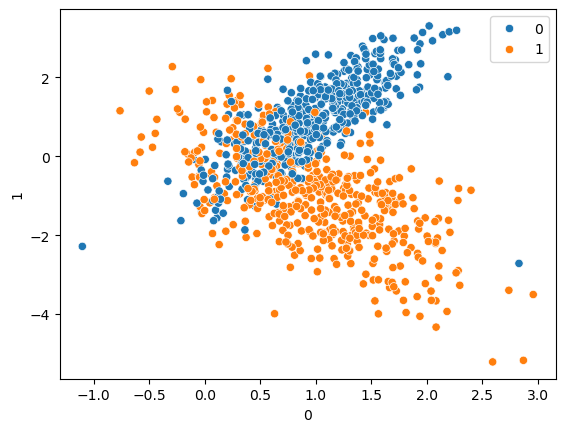

In [9]:
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0000)

In [11]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(x_train,y_train)

SVC(kernel='linear')

In [12]:
y_pred = svc.predict(x_test)

In [13]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
a = accuracy_score(y_pred,y_test)
cm = confusion_matrix(y_pred,y_test)
cr = classification_report(y_test,y_pred)
print(a)
print(cm)
print(cr)


0.792
[[101  30]
 [ 22  97]]
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       123
           1       0.82      0.76      0.79       127

    accuracy                           0.79       250
   macro avg       0.79      0.79      0.79       250
weighted avg       0.79      0.79      0.79       250



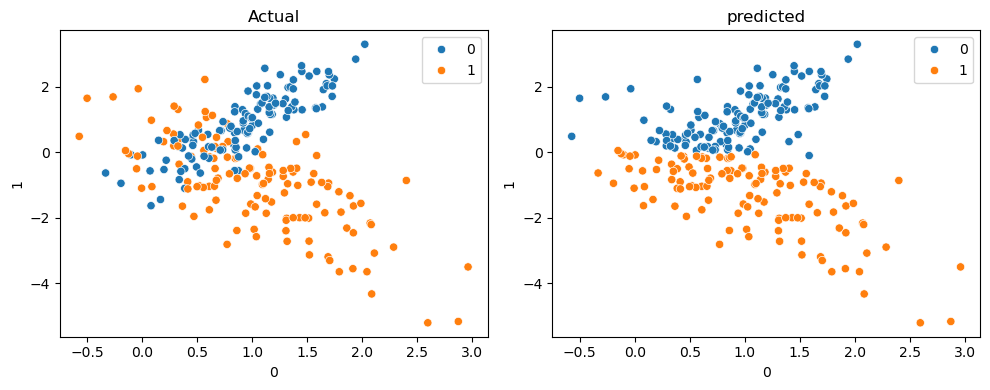

In [23]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(x=pd.DataFrame(x_test)[0],y=pd.DataFrame(x_test)[1],hue=y_test)
plt.title("Actual")

plt.subplot(1, 2, 2)
sns.scatterplot(x=pd.DataFrame(x_test)[0],y=pd.DataFrame(x_test)[1],hue=y_pred)
plt.title("predicted")

plt.tight_layout() 
plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV
params_g = { 'C':[0.1,1,10,100,1000],
            'gamma': [1,0.1,0.01,0.001,0.0001],
            'kernel':['rbf']}

In [25]:
grid = GridSearchCV(SVC(),param_grid=params_g,refit=True,cv=5,verbose=3)

In [26]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.873 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.867 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.873 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.807 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.820 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.827 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.813 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.847 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.780 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.793 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.840 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [30]:
grid.best_params_
y_predc = grid.predict(x_test)

In [31]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
a = accuracy_score(y_predc,y_test)
cm = confusion_matrix(y_predc,y_test)
cr = classification_report(y_test,y_predc)
print(a)
print(cm)
print(cr)


0.832
[[107  26]
 [ 16 101]]
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       123
           1       0.86      0.80      0.83       127

    accuracy                           0.83       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.83      0.83       250

